In [1]:
import numpy as np 
import pandas as pd 
from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping
import os
import datetime 
import random
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.metrics import confusion_matrix
start_time = datetime.datetime.now()


In [3]:
# 1. Load the dataset and diving into the training and test data set
def get_dataset(directory,type_of_data="train",IMAGE_SIZE=(48,48),num_classes=43):
    X = [] 
    y = [] 
    
    # Iterate through image folders
    for i in range(num_classes):
        path = os.path.join(directory,type_of_data,str(i)) 
        
        # List all the images in the folder
        for j in os.listdir(path):  
            
            # Open the image
            image = Image.open(path + '/'+ j) 
            
            # Resize it to (48,48)
            image = image.resize(IMAGE_SIZE) 
            
            # Convert it to a numpy array for easier use
            image = np.array(image) 
            
            # Add the image and the labels to the lists
            X.append(image) 
            y.append(i)
            
    return np.array(X), np.array(y)

In [4]:
def plot_label_distribution(labels, class_names):
    # Convert labels to numpy array if not already
    labels = np.array(labels)

    # Count the number of images for each label
    label_counts = np.bincount(labels)

    # Plot the distribution
    plt.figure(figsize=(10, 6))
    plt.bar(class_names, label_counts)
    plt.xlabel('Class Name')
    plt.ylabel('Number of Images')
    plt.title('Distribution of Images Across Classes')
    plt.xticks(rotation=90)  # Rotate x-axis labels to vertical orientation
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

In [5]:
def plot_confusion_matrix(true_values, predicted_values, classes, save_figure=False, filename=None, figsize=(8, 6)):
    """
    Plots a confusion matrix for a deep neural network.

    Parameters:
    true_values (array-like): Array of true class labels.
    predicted_values (array-like): Array of predicted class labels.
    classes (list): List of class names.
    save_figure (bool): Whether to save the figure or not.
    filename (str): Filename to save the figure (if save_figure is True).
    figsize (tuple): Size of the figure (width, height).
    
    Returns:
    None
    """
    # Compute confusion matrix
    cm = confusion_matrix(true_values, predicted_values)
    
    # Plot confusion matrix
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', xticklabels=classes, yticklabels=classes, annot_kws={"fontsize":10})
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.title('Confusion Matrix')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    # Save the figure if specified
    if save_figure and filename:
        plt.savefig(filename)
    
    plt.show()

In [6]:
def load_image(path,rgba=False):
    loaded_image = Image.open(path)
    if rgba:
        loaded_image = loaded_image.convert("RGB")
    loaded_image = loaded_image.resize((48,48))
    loaded_image = np.array(loaded_image)
    loaded_image = np.expand_dims(loaded_image,axis=0)
    return loaded_image

In [7]:
def calculate_results(y_true, y_pred):
    # Calculate model accuracy
    model_accuracy = accuracy_score(y_true, y_pred) * 100
    # Calculate model precision, recall and f1 score using "weighted average
    model_precision, model_recall, model_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    model_results = {"accuracy": model_accuracy,
                  "precision": model_precision,
                  "recall": model_recall,
                  "f1": model_f1}
    return model_results

In [11]:
directory = "/Users/maliya/Desktop/dissertation/Vista/data/raw/consolidated/gtsrb-german-traffic-sign"
IMAGE_SIZE = (96,96)
SMALL_IMAGE_SIZE = (48,48) 
num_classes = 43
sign_names = ["limit_zone_20","limit_zone_30","limit_zone_50","limit_zone_60","limit_zone_70",
              "limit_zone_80","end_of_speed_limit","limit_zone_100","limit_zone_120",
              "no_passing","no_passing_for_trucks","right_of_way","priority_road",
              "yield_right_of_way","stop","prohibited_for_all_vehicles","tractors_and_trucks_prohibited",
              "entry_prohibited","danger","single_curve_left","single_curve_right","double_curve",
              "rough_road","slippery_road","road_narrows","construction_site","signal_lights_ahead","pedestrian_crosswalk_ahead",
              "children","bicycle_crossing","snow_ahead","wild_animal_crossing","end_of_all_restrictions",
               "mandatory_right","mandatory_left","mandatory_ahead","mandatory_ahead_right",
              "mandatory_ahead_left","mandatory_down_right","mandatory_down_left","traffic_circle","end_of_no_passing_zone",
              "end_of_no_passing_zone_trucks"]
train_data, train_labels = get_dataset(directory=directory,
                                      type_of_data="train",
                                      IMAGE_SIZE=SMALL_IMAGE_SIZE,
                                      num_classes=num_classes)

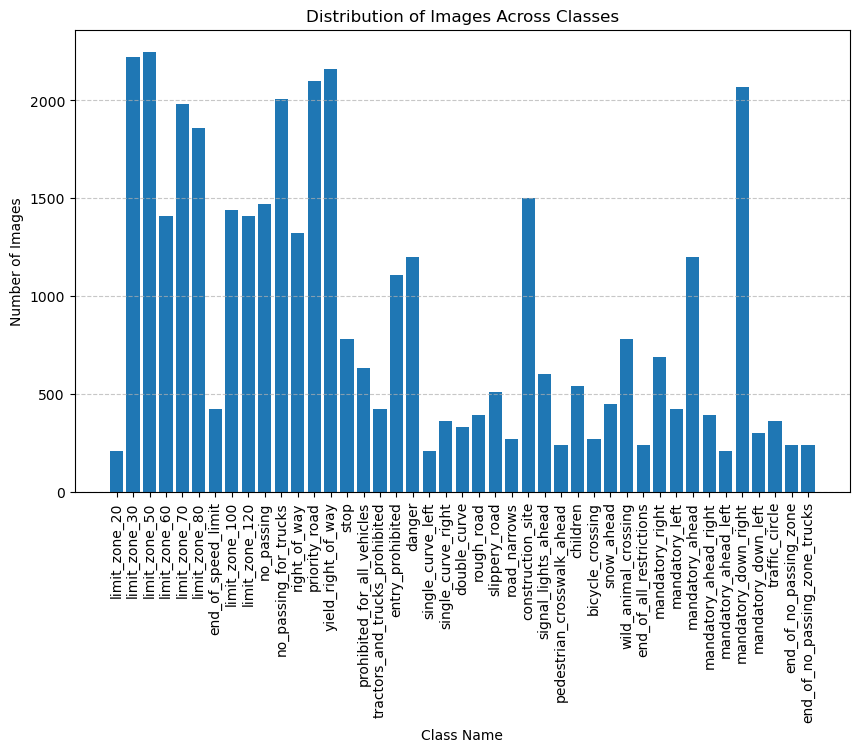

In [12]:
plot_label_distribution(train_labels,sign_names)

In [14]:
# Split the dataset into training and validation sets
x_train, x_valid, y_train, y_valid = train_test_split(train_data, 
                                                    train_labels, 
                                                    test_size=0.2, 
                                                    random_state=42)
y_train = to_categorical(y_train, 43)
y_valid = to_categorical(y_valid, 43)
train_dataset = tf.data.Dataset.zip((
    tf.data.Dataset.from_tensor_slices(x_train),
    tf.data.Dataset.from_tensor_slices(y_train)
))

valid_dataset = tf.data.Dataset.zip((
    tf.data.Dataset.from_tensor_slices(x_valid),
    tf.data.Dataset.from_tensor_slices(y_valid)
))

In [15]:
def normalize_img(image,label):
    return tf.cast(image,tf.float32)/255., label

#Apply normalization and prefetching
train_dataset = train_dataset.map(normalize_img,num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)
valid_dataset = valid_dataset.map(normalize_img,num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)

In [16]:
checkpoint_callback = ModelCheckpoint(
    filepath='model_checkpoint.keras',  # Filepath to save the model
    monitor='val_loss',               # Quantity to monitor
    save_best_only=True,              # Save only the best models
    verbose=1                          # Verbosity level (0 or 1)
)
reduce_lr_callback = ReduceLROnPlateau(
    monitor='val_loss',       # Quantity to monitor
    factor=0.1,               # Factor by which the learning rate will be reduced. new_lr = lr * factor
    patience=4,               # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=1e-6,              # Lower bound on the learning rate
    verbose=1                 # Verbosity level (0 or 1) 
)
early_stopping_callback = EarlyStopping(monitor='val_loss',
                                        patience=8,

)

In [17]:
inputs = Input(shape=(48,48,3), name="input_layer")

conv_1 = Conv2D(filters=96, kernel_size=7,activation="relu")(inputs)
max_pool_1 = MaxPool2D()(conv_1)
conv_2 = Conv2D(128, kernel_size=4,activation="relu")(max_pool_1)
max_pool_2 = MaxPool2D()(conv_2)
conv_3 = Conv2D(256, kernel_size=4,activation="relu")(max_pool_2)
max_pool_3 = MaxPool2D()(conv_3)
flat = Flatten()(max_pool_3)
dense_1 = Dense(256, activation="relu")(flat)

outputs = Dense(num_classes, activation="softmax")(dense_1)

model = tf.keras.Model(inputs,outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 42, 42, 96)     │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 21, 21, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 18, 18, 128)    │       196,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 6, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,336,619 (5.10 MB)

 Trainable params: 1,336,619 (5.10 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(loss="categorical_crossentropy",
                  optimizer=Adam(),
                  metrics=["accuracy","precision","recall"])

history = model.fit(train_dataset,
                    epochs=100,
                    validation_data=valid_dataset,
                    callbacks=[reduce_lr_callback,early_stopping_callback,checkpoint_callback])

Epoch 1/100
980/981 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.5600 - loss: 1.6431 - precision: 0.8382 - recall: 0.4585
Epoch 1: val_loss improved from inf to 0.13120, saving model to model_checkpoint.keras
981/981 ━━━━━━━━━━━━━━━━━━━━ 1496s 2s/step - accuracy: 0.5605 - loss: 1.6413 - precision: 0.8384 - recall: 0.4590 - val_accuracy: 0.9657 - val_loss: 0.1312 - val_precision: 0.9727 - val_recall: 0.9586 - learning_rate: 0.0010
Epoch 2/100
980/981 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9717 - loss: 0.1000 - precision: 0.9785 - recall: 0.9652
Epoch 2: val_loss improved from 0.13120 to 0.07840, saving model to model_checkpoint.keras
981/981 ━━━━━━━━━━━━━━━━━━━━ 1405s 1s/step - accuracy: 0.9717 - loss: 0.0999 - precision: 0.9785 - recall: 0.9652 - val_accuracy: 0.9814 - val_loss: 0.0784 - val_precision: 0.9866 - val_recall: 0.9779 - learning_rate: 0.0010
Epoch 3/100
980/981 ━━━━━━━━━━━━━━━━━━━━ 5s 6s/step - accuracy: 0.9874 - loss: 0.0425 - precision: 0.9894 - recall: 0.9846 
Ep

In [19]:
inputs = Input(shape=(48,48,3), name="input_layer")
conv_1 = Conv2D(filters=64, kernel_size=5,activation="relu")(inputs)
conv_2 = Conv2D(filters=64, kernel_size=5,activation="relu")(conv_1)
max_pool_1 = MaxPool2D()(conv_2)
conv_3 = Conv2D(48, kernel_size=3,activation="relu")(max_pool_1)
conv_4 = Conv2D(48, kernel_size=3,activation="relu")(conv_3)
max_pool_2 = MaxPool2D()(conv_4)
dropout = Dropout(0.3)(max_pool_2)
flat = Flatten()(dropout)
dense_1 = Dense(256, activation="relu")(flat)
outputs = Dense(num_classes, activation="softmax")(dense_1)
model2 = tf.keras.Model(inputs,outputs)

model2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 44, 44, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 40, 40, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 18, 18, 48)     │        27,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 953,547 (3.64 MB)

 Trainable params: 953,547 (3.64 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model2.compile(loss="categorical_crossentropy",
                  optimizer=Adam(),
                  metrics=["accuracy","precision","recall"])

history2 = model2.fit(train_dataset,
                    epochs=100,
                    validation_data=valid_dataset,
                    callbacks=[reduce_lr_callback,early_stopping_callback,checkpoint_callback])

Epoch 1/100
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.6584 - loss: 1.3126 - precision: 0.8565 - recall: 0.5754
Epoch 1: val_loss did not improve from 0.04073
981/981 ━━━━━━━━━━━━━━━━━━━━ 627s 638ms/step - accuracy: 0.6586 - loss: 1.3118 - precision: 0.8566 - recall: 0.5756 - val_accuracy: 0.9749 - val_loss: 0.0980 - val_precision: 0.9824 - val_recall: 0.9660 - learning_rate: 0.0010
Epoch 2/100
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9771 - loss: 0.0858 - precision: 0.9824 - recall: 0.9717
Epoch 2: val_loss did not improve from 0.04073
981/981 ━━━━━━━━━━━━━━━━━━━━ 8181s 8s/step - accuracy: 0.9771 - loss: 0.0858 - precision: 0.9824 - recall: 0.9717 - val_accuracy: 0.9830 - val_loss: 0.0713 - val_precision: 0.9870 - val_recall: 0.9799 - learning_rate: 0.0010
Epoch 3/100
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.9844 - loss: 0.0539 - precision: 0.9868 - recall: 0.9810 
Epoch 3: val_loss improved from 0.04073 to 0.04048, saving model to model_checkp